[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509Files/blob/main/OPIM5509_Module1_Files/Assignment1_OPIM5509.ipynb)

# Individual Assignment 1: ML Modeling Refresh


**OPIM 5509: Introduction to Deep Learning - University of Connecticut**

* Full Name: George Khramtchenko
* Student ID (7 digit number): 3325515

---------------------------------------------------------------------------

Each student must complete and submit their own file, but you may work with your group for help. I do not want to see direct copy and pasted code otherwise you will get a zero. This is a dataset on annual earnings (y) as a function of geographic and economic predictors.

**10 points each. 100 points**

  Use the file below to complete the following data wrangling and regression modeling. Good luck!


# Read the data

For some reason, gdown has recently been giving me issues - so here you can download and drag the file into your runtime.

Here is the link for:

* X_S24.csv = https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module1_Files/X_S24.csv
* y_S24.csv = https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module1_Files/y_S24.csv

In [23]:
# Import required modules
import pandas as pd # for data analysis
import numpy as np # for numeric functions
import matplotlib.pyplot as plt # for plotting
import seaborn as sns # for enhanced plotting
from sklearn.preprocessing import MinMaxScaler

# Set display options to show all columns
pd.set_option('display.max_columns', None)

In [24]:
# https://drive.google.com/file/d/1WG7yo5jJVJMMUlN1h3EtUYZKuJZVAYXP/view?usp=sharing
!gdown 1WG7yo5jJVJMMUlN1h3EtUYZKuJZVAYXP
X_S24 = pd.read_csv('X_S24.csv')

Downloading...
From: https://drive.google.com/uc?id=1WG7yo5jJVJMMUlN1h3EtUYZKuJZVAYXP
To: /content/X_S24.csv
100% 982k/982k [00:00<00:00, 76.5MB/s]


In [25]:
# https://drive.google.com/file/d/1qoLMISRbMBCtwYSMm_bEtPdc2ecJAO9_/view?usp=sharing
!gdown 1qoLMISRbMBCtwYSMm_bEtPdc2ecJAO9_
y_S24 = pd.read_csv('y_S24.csv')

Downloading...
From: https://drive.google.com/uc?id=1qoLMISRbMBCtwYSMm_bEtPdc2ecJAO9_
To: /content/y_S24.csv
100% 56.3k/56.3k [00:00<00:00, 51.3MB/s]


# Q1. Explore the dataset
Get to know this new dataset! How many rows and columns are there? What are the data types of the columns in X (string vs numeric)? Are there any missing values?

In [26]:
X_S24.shape

(5000, 10)

In [27]:
X_S24.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   State Score                                5000 non-null   float64
 1   Education Score                            5000 non-null   float64
 2   Geography Score                            5000 non-null   float64
 3   Age (normalized)                           5000 non-null   float64
 4   Career Advancement Opportunity Score       5000 non-null   float64
 5   Job Satisfaction Score                     5000 non-null   float64
 6   Health and Wellness Program Quality Score  5000 non-null   float64
 7   Job Demand Score                           5000 non-null   float64
 8   Work Experience (normalized)               5000 non-null   float64
 9   Company Size (normalized)                  5000 non-null   float64
dtypes: float64(10)
memory us

In [28]:
y_S24.shape

(5000, 1)

In [29]:
X_S24.isnull().any()

,0
State Score,False
Education Score,False
Geography Score,False
Age (normalized),False
Career Advancement Opportunity Score,False
Job Satisfaction Score,False
Health and Wellness Program Quality Score,False
Job Demand Score,False
Work Experience (normalized),False
Company Size (normalized),False


**Answer:** There are **5000 rows** and **10 columns** in the **X_S24** dataset, and **5,000 rows** with just **one column** in the **y_S24** dataset. The data types of the columns in the X_S24 dataset are numeric, specifically float64, with no missing values.

# Q2. Split into X_train, X_test, y_train, y_test.
Before we do any cleaning, let's split the data so that we can use fit_transform() on train and transform() on test. Use an 80/20 split, shuffle the data, and random state equal to **YOUR STUDENT ID**. Print the shape of X_train, X_test, y_train, y_test and make sure it makes sense to you.

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_S24, y_S24, test_size=0.2, random_state=3325515)

# Print the shape of X_train, X_test, y_train, y_test
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4000, 10)
Shape of X_test: (1000, 10)
Shape of y_train: (4000, 1)
Shape of y_test: (1000, 1)


In [31]:
# Convert these all to numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

*This looks accurate, I think we're all good here!*

# Q3. Clean up the dataset.
Use your judgement on if any rows should be deleted - there are missing values in every column in X that need to get replaced!

Right now X and y are in different files, so be careful if you are dropping rows.

*Check the **X_S24** and **y_S24** datasets to see if any columns are missing values, and if so, use best judgement to decide whether any rows should be deleted or kept.*

In [32]:
X_S24.isnull().any()

,0
State Score,False
Education Score,False
Geography Score,False
Age (normalized),False
Career Advancement Opportunity Score,False
Job Satisfaction Score,False
Health and Wellness Program Quality Score,False
Job Demand Score,False
Work Experience (normalized),False
Company Size (normalized),False


In [33]:
y_S24.isnull().any()

,0
Annual Earnings,False


**Answer:** There are no missing values in either the **X_S24** or **y_S24** datasets, therefore, no rows will be dropped. No other actions will be performed at this time.

# Q4. Make three EDA plots and three EDA tables using X_train and y_train

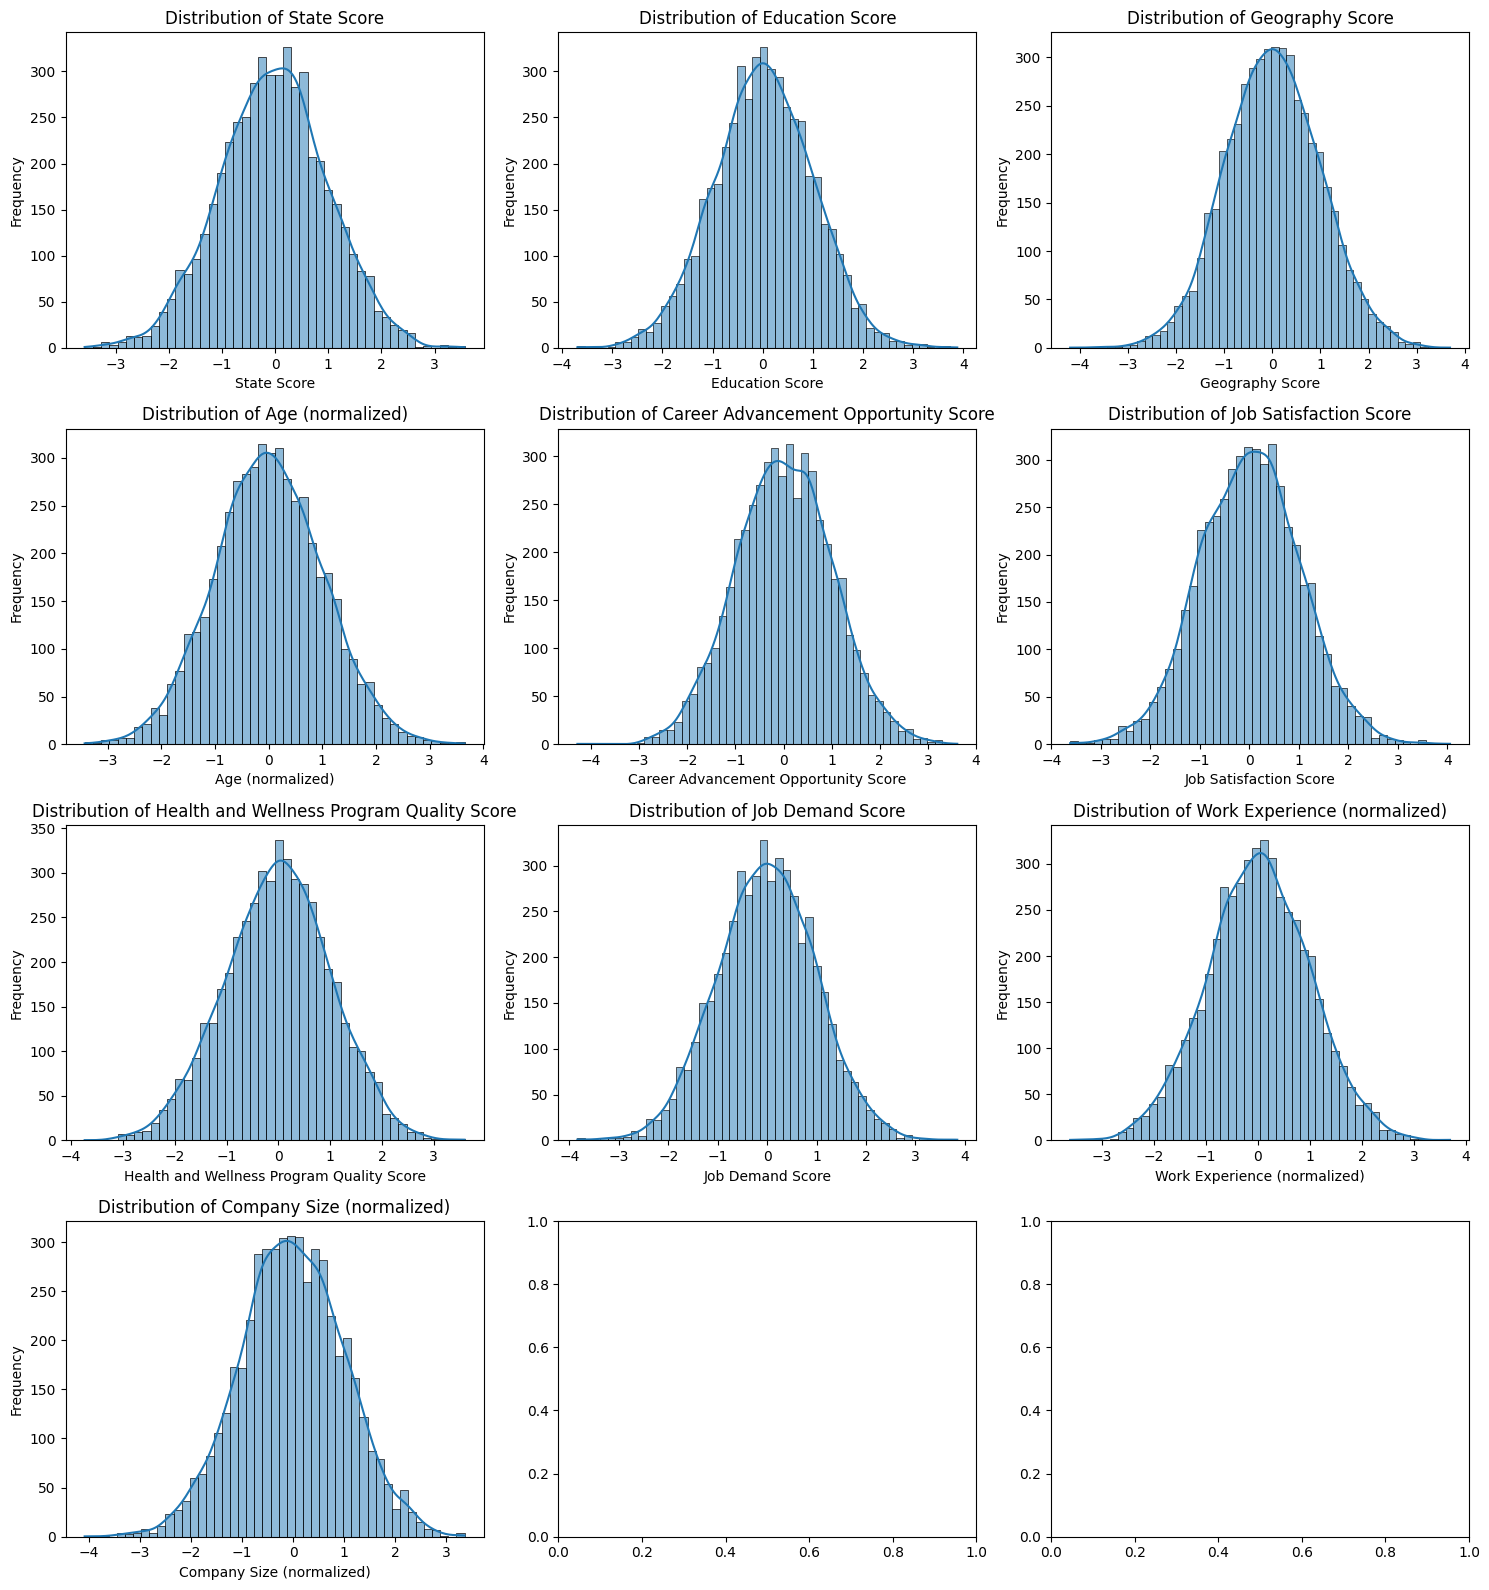

In [34]:
# Get the number of features, set grid columns and rows
num_features = X_S24.shape[1]
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

# Create a figure and a set of subplots
# Assisted by Gemini AI
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))

# Flatten the axes array for easy iteration if it's 2D
# Assisted by Gemini AI
axes = axes.flatten() if num_rows > 1 else axes

# Iterate through each feature and plot its histogram
for i, column in enumerate(X_S24.columns):
    ax = axes[i]
    sns.histplot(X_S24[column], kde=True, ax=ax)
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

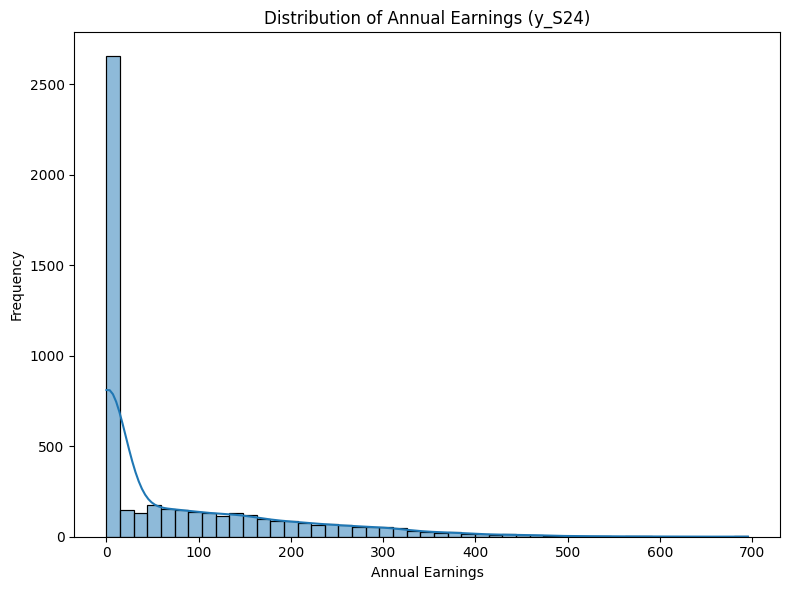

In [35]:
plt.figure(figsize=(8, 6))
sns.histplot(y_S24['Annual Earnings'], kde=True)
plt.title('Distribution of Annual Earnings (y_S24)')
plt.xlabel('Annual Earnings')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [36]:
X_S24.describe()

,State Score,Education Score,Geography Score,Age (normalized),Career Advancement Opportunity Score,Job Satisfaction Score,Health and Wellness Program Quality Score,Job Demand Score,Work Experience (normalized),Company Size (normalized)
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,-0.028652,0.018241,0.015757,0.004890,0.012961,0.018218,-0.005375,-0.008035,0.016715,-0.016981
std,1.008419,0.985117,0.985917,0.998210,0.999196,1.009253,1.017983,0.996555,0.981910,1.017218
min,-3.581230,-3.696449,-4.199683,-3.429597,-4.281627,-3.618401,-3.740454,-3.838710,-3.611576,-4.088482
25%,-0.705773,-0.634969,-0.649327,-0.667627,-0.661581,-0.688040,-0.690529,-0.671862,-0.636700,-0.689913
50%,-0.020192,0.012030,0.003570,-0.007196,0.012131,0.025922,0.008622,-0.006657,0.018452,-0.025886
75%,0.631780,0.686435,0.676724,0.673112,0.685889,0.687442,0.676509,0.667588,0.687485,0.667343
max,3.561219,3.877207,3.691489,3.649854,3.609161,4.052979,3.595347,3.847528,3.693792,3.361579


Correlation Matrix for X_S24:


,State Score,Education Score,Geography Score,Age (normalized),Career Advancement Opportunity Score,Job Satisfaction Score,Health and Wellness Program Quality Score,Job Demand Score,Work Experience (normalized),Company Size (normalized)
State Score,1.000000,0.006681,-0.012649,0.005007,-0.001363,-0.003802,-0.014804,-0.004681,-0.002458,-0.001301
Education Score,0.006681,1.000000,0.013498,0.006953,-0.015850,-0.012631,0.005155,-0.006381,-0.017428,0.005339
Geography Score,-0.012649,0.013498,1.000000,0.024422,-0.001233,-0.022433,0.011277,-0.024199,-0.000328,0.002815
Age (normalized),0.005007,0.006953,0.024422,1.000000,-0.005937,0.023867,-0.009237,-0.008579,0.021520,-0.009830
Career Advancement Opportunity Score,-0.001363,-0.015850,-0.001233,-0.005937,1.000000,-0.022429,0.004526,-0.012064,0.001605,-0.018930
Job Satisfaction Score,-0.003802,-0.012631,-0.022433,0.023867,-0.022429,1.000000,0.003051,-0.011679,-0.014813,-0.016654
Health and Wellness Program Quality Score,-0.014804,0.005155,0.011277,-0.009237,0.004526,0.003051,1.000000,0.003987,-0.001704,0.004262
Job Demand Score,-0.004681,-0.006381,-0.024199,-0.008579,-0.012064,-0.011679,0.003987,1.000000,-0.016684,0.003007
Work Experience (normalized),-0.002458,-0.017428,-0.000328,0.021520,0.001605,-0.014813,-0.001704,-0.016684,1.000000,0.010929
Company Size (normalized),-0.001301,0.005339,0.002815,-0.009830,-0.018930,-0.016654,0.004262,0.003007,0.010929,1.000000


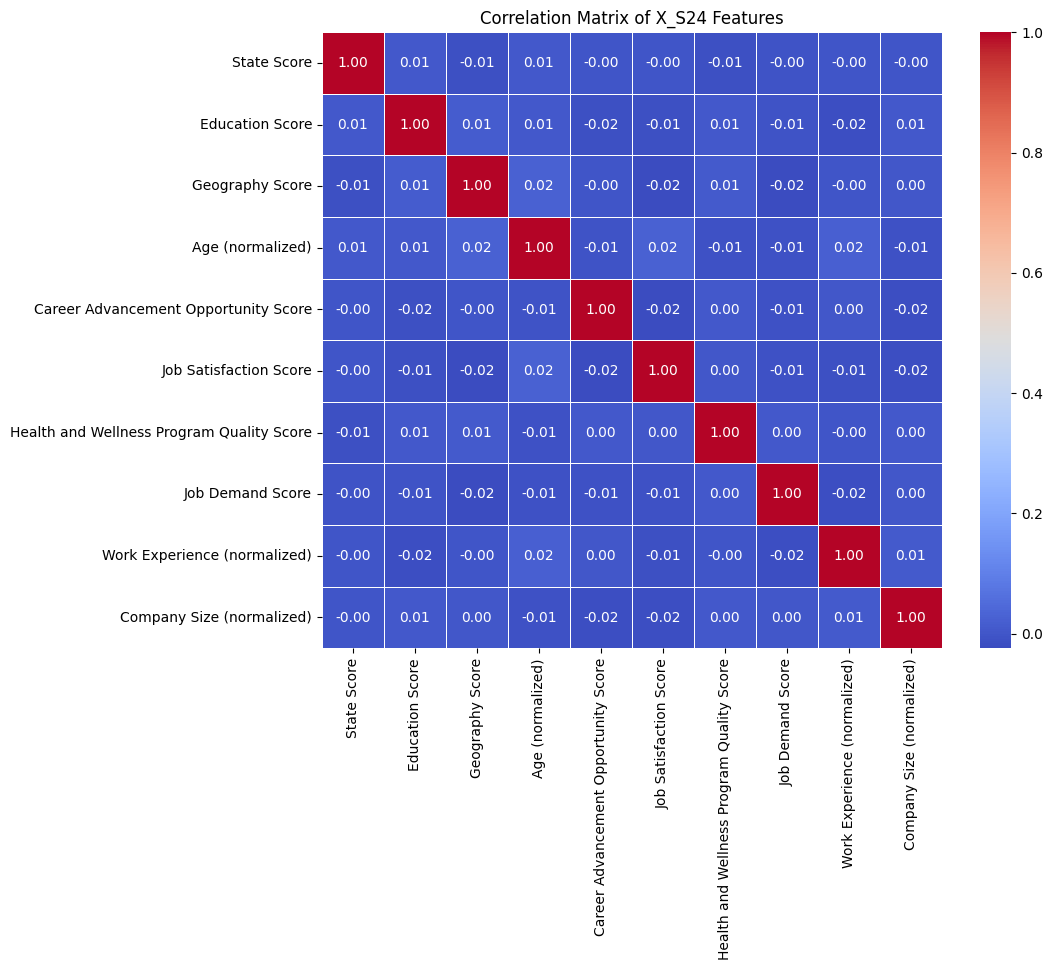

In [37]:
# Correlation matrix for X_S24
correlation_matrix = X_S24.corr()

# Display numerical correlation matrix
print("Correlation Matrix for X_S24:")
display(correlation_matrix)

# Plot heatmap representation of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of X_S24 Features')
plt.show()

# Q5. Subset columns for X
Use every column in `X` except 'State Score' to build your model.

  **Useful link for subsetting rows and columns:** https://www.kdnuggets.com/2019/06/select-rows-columns-pandas.html

In [38]:
# Create a new X_S24_sub DataFrame to exclude 'State Score' column
X_S24_sub = X_S24.drop(columns=['State Score'])

# Verify changes have occured
print("Shape of X_S24_sub:", X_S24_sub.shape)
print("Columns in X_S24_sub:", X_S24_sub.columns.tolist())

Shape of X_S24_sub: (5000, 9)
Columns in X_S24_sub: ['Education Score', 'Geography Score', 'Age (normalized)', 'Career Advancement Opportunity Score', 'Job Satisfaction Score', 'Health and Wellness Program Quality Score', 'Job Demand Score', 'Work Experience (normalized)', 'Company Size (normalized)']


# Q6. Use fit_transform() from StandardScaler() on X_train. Use transform() to apply that StandardScaler() to X_test.


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Q7. Fit a random forest regressor (or any other sklearn) model on X_train. Call your model object `clf`.

Then create two new variables, `train_preds` and `test_preds`, which are the predictions from your model. For example, you will use `train_preds = clf.predict(X_train)` for `X_train` . Calculate error metrics of MAE and R2 for train and test results.

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and fit the Random Forest Regressor model
clf = RandomForestRegressor(random_state=3325515)
clf.fit(X_train, y_train.ravel())

# Make predictions on training and test sets
train_preds = clf.predict(X_train)
test_preds = clf.predict(X_test)

# Calculate error metrics for train and test results
train_mae = mean_absolute_error(y_train, train_preds)
train_r2 = r2_score(y_train, train_preds)

test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

# Print the calculated error metrics of MAE and R2
print(f"Training MAE: {train_mae:.2f}")
print(f"Training R2: {train_r2:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test R2: {test_r2:.2f}")

Training MAE: 11.03
Training R2: 0.98
Test MAE: 29.28
Test R2: 0.84


# Q8. Make two scatterplots of actual vs. predicted. One for train results, one for test results.
With nicely labeled title and axis (like we did in class).

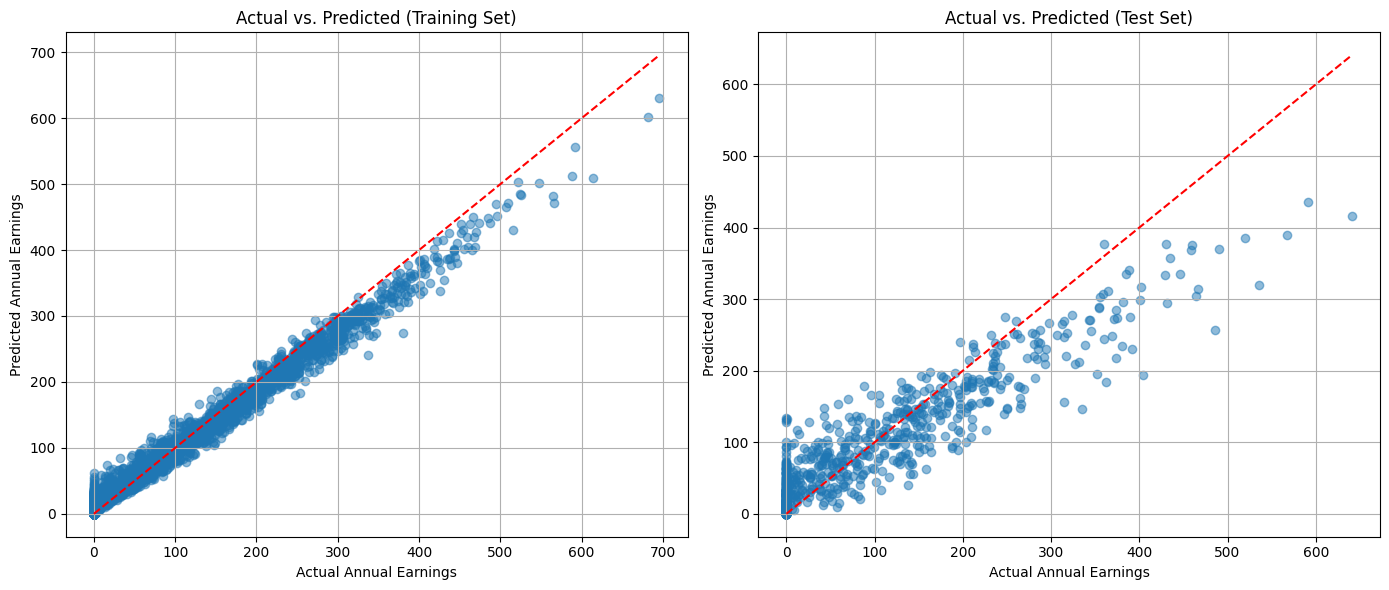

In [41]:
plt.figure(figsize=(14, 6))

# Plot for training set
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.scatter(y_train, train_preds, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--') # Red dashed line for ideal prediction
plt.title('Actual vs. Predicted (Training Set)')
plt.xlabel('Actual Annual Earnings')
plt.ylabel('Predicted Annual Earnings')
plt.grid(True)

# Plot for test set
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.scatter(y_test, test_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Red dashed line for ideal prediction
plt.title('Actual vs. Predicted (Test Set)')
plt.xlabel('Actual Annual Earnings')
plt.ylabel('Predicted Annual Earnings')
plt.grid(True)

plt.tight_layout()
plt.show()

# Q9. Try a simple model - does it work?

Examine variable importance and build a simpler model (you can use tree importance from random forest or permutation importance.) You are building a model with less features, so it should be as good or slightly less better than your current model.

* https://scikit-learn.org/stable/modules/permutation_importance.html
* https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

Calculate error metrics and make one scatterplot of actual vs. predicted results for this new holdout sample.

Were you able to get similar results?

In [42]:
from sklearn.model_selection import train_test_split

# Use an 80/20 split, shuffle the data, and set random state equal to my student ID (3325515)
# Using X_S24_sub as per Q5 instructions
X_train, X_test, y_train, y_test = train_test_split(X_S24_sub, y_S24, test_size=0.2, random_state=3325515)

# Print the shape of X_train, X_test, y_train, y_test
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4000, 9)
Shape of X_test: (1000, 9)
Shape of y_train: (4000, 1)
Shape of y_test: (1000, 1)


In [43]:
# convert these all to numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

Permutation Importances:


,feature,importance,std
6,Job Demand Score,0.391303,0.031817
4,Job Satisfaction Score,0.371594,0.021157
3,Career Advancement Opportunity Score,0.271145,0.015103
1,Geography Score,0.179179,0.022331
5,Health and Wellness Program Quality Score,0.162572,0.014834
8,Company Size (normalized),0.003039,0.001403
2,Age (normalized),0.002226,0.001162
7,Work Experience (normalized),0.001764,0.001534
0,Education Score,-0.001480,0.001643


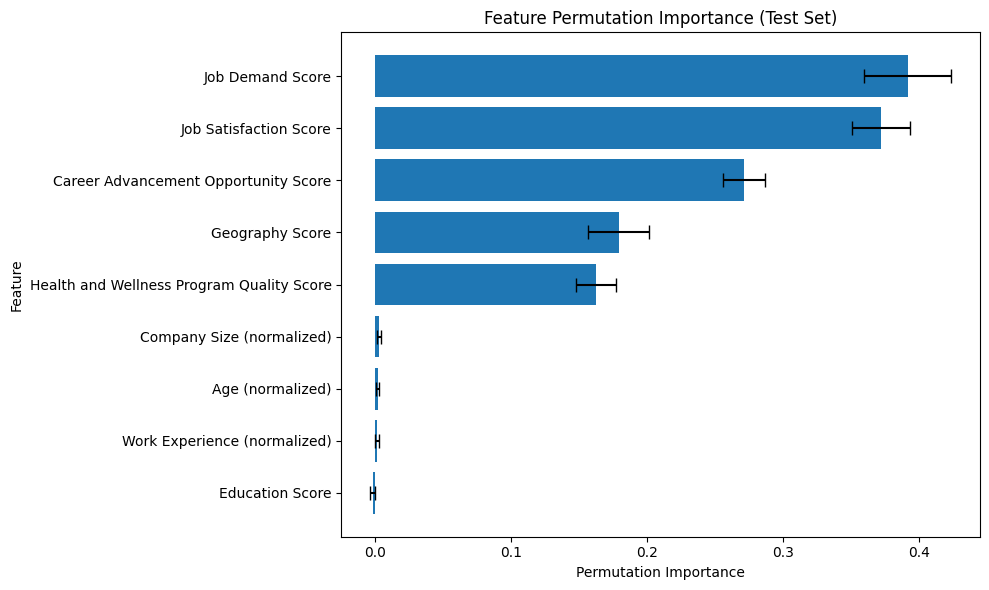


Selected top 5 features for simpler model: ['Job Demand Score', 'Job Satisfaction Score', 'Career Advancement Opportunity Score', 'Geography Score', 'Health and Wellness Program Quality Score']
Shape of X_train_simple: (4000, 5)
Shape of X_test_simple: (1000, 5)

RandomForestRegressor Model Training MAE: 14.43
RandomForestRegressor Model Training R2: 0.96
RandomForestRegressor Model Test MAE: 39.93
RandomForestRegressor Model Test R2: 0.69


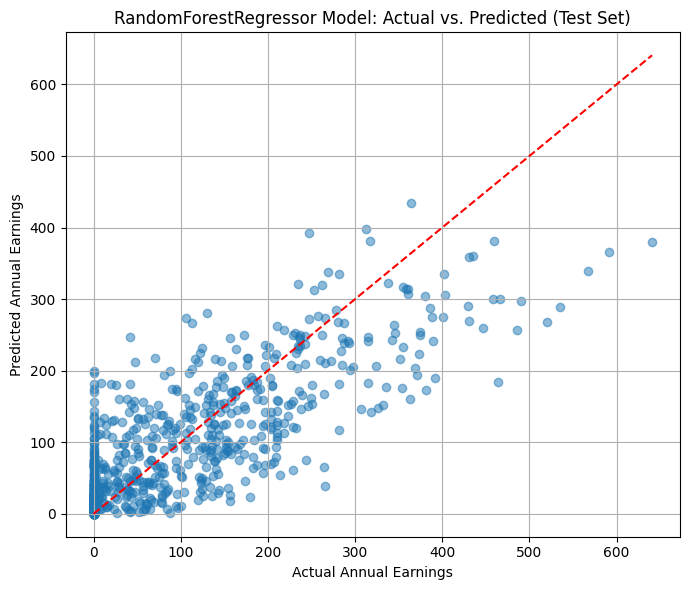

In [44]:
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

# Reapply StandardScaler to the new X_train and X_test (9 features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestRegressor(random_state=3325515)
clf.fit(X_train_scaled, y_train.ravel())

# Calculate permutation importance using new model, get feature names
result = permutation_importance(clf, X_test_scaled, y_test.ravel(), n_repeats=10, random_state=3325515, n_jobs=-1)
feature_names = X_S24_sub.columns.tolist()

# Create a new 'importance_df' DataFrame for future visualization
importance_df = pd.DataFrame({'feature': feature_names, 'importance': result.importances_mean, 'std': result.importances_std})
importance_df = importance_df.sort_values(by='importance', ascending=False)

print("Permutation Importances:")
display(importance_df)

# Display permutation importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], xerr=importance_df['std'], capsize=5)
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title('Feature Permutation Importance (Test Set)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Select 5 top features
top_n_features = 5
selected_features_df = importance_df.head(top_n_features)
selected_feature_names = selected_features_df['feature'].tolist()
print(f"\nSelected top {top_n_features} features for simpler model: {selected_feature_names}")

# Gemini AI Assistance
# Get the indices of the selected features from the original X_S24_sub columns
# X_S24_sub.columns has the correct order of features in X_train and X_test numpy arrays
original_feature_names = X_S24_sub.columns.tolist()
selected_feature_indices = [original_feature_names.index(feat) for feat in selected_feature_names]

# Create new X_train and X_test with only the selected features from the scaled data
X_train_simple = X_train_scaled[:, selected_feature_indices]
X_test_simple = X_test_scaled[:, selected_feature_indices]

print(f"Shape of X_train_simple: {X_train_simple.shape}")
print(f"Shape of X_test_simple: {X_test_simple.shape}")

# Train new Random Forest Regressor model and make predictions
clf_simple = RandomForestRegressor(random_state=3325515)
clf_simple.fit(X_train_simple, y_train.ravel())

train_preds_simple = clf_simple.predict(X_train_simple)
test_preds_simple = clf_simple.predict(X_test_simple)

# Calculate error metrics
train_mae_simple = mean_absolute_error(y_train, train_preds_simple)
train_r2_simple = r2_score(y_train, train_preds_simple)
test_mae_simple = mean_absolute_error(y_test, test_preds_simple)
test_r2_simple = r2_score(y_test, test_preds_simple)

print(f"\nRandomForestRegressor Model Training MAE: {train_mae_simple:.2f}")
print(f"RandomForestRegressor Model Training R2: {train_r2_simple:.2f}")
print(f"RandomForestRegressor Model Test MAE: {test_mae_simple:.2f}")
print(f"RandomForestRegressor Model Test R2: {test_r2_simple:.2f}")

# Plot actual vs. predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_preds_simple, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('RandomForestRegressor Model: Actual vs. Predicted (Test Set)')
plt.xlabel('Actual Annual Earnings')
plt.ylabel('Predicted Annual Earnings')
plt.grid(True)
plt.tight_layout()
plt.show()

* As mentioned previously, this dataset contained 5,000 rows and 10 columns for the features `(X_S24)` and 5,000 rows with just one column for the target `(y_S24)` variable. As all of the features were numerical (float64), and no missing values were located, cleaning the data was very easy. I learned how important it is to observe the shape of the data in order to be able to understand and track the changes that are made to it.

* Subsetting my data and selecting the most significant features allowed me to understand that 'Job Demand Score', Job Satisfaction Score', 'Career Advancement Opportunity Score', 'Geography Score', and 'Health and Wellness Program Quality Score' were the top 5 most significant features. By building a new RFG model with only these significant features, I assumed my results would prove to be more reliable, as the model's complexity was significantly reduced compared to the original one.

* The original RFG model achieved a training R2 of 0.98 and a test R2 of 0.84, with train MAE equal to 11.03 (train) and test MAE equal to 29.28. These results suggested a good fit on the training data provided but with some room for improvement to raise the R2 score.

* The new RFG model, unfortunately, did not yield better results when focusing exclusively on R2 scores. Upon training it on only the significant features, the model achieved a training R2 of 0.96 and a test R2 of 0.69, with train MAE equal to 14.43 and test MAE equal to 39.93. These results suggest a poor fit with the training data. Likely, hyperparameter tuning is necessary to further improve on these results but was not actively explored for this assignment.

* Finally, I learned the importance of scaling and transforming my data, as doing so is crucial for preventing data leakage and ensuring models generalize well.